Download source data from this url:
https://www.smhi.se/data/meteorologi/ladda-ner-meteorologiska-observationer/#param=airtemperatureInstant,stations=all

In [343]:
import os 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

df = pd.read_csv(r'data\smhi-opendata_1_52350_20220419_085636.csv',skiprows=range(9),delimiter=";",usecols=['Datum','Tid (UTC)','Lufttemperatur'])
#Weather station was moved 1995-11. Remove data from before that so that all data represents the same exact location 
df = df[df["Datum"] > "1995-11-01"]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 227505 entries, 49034 to 276538
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Datum           227505 non-null  object 
 1   Tid (UTC)       227505 non-null  object 
 2   Lufttemperatur  227505 non-null  float64
dtypes: float64(1), object(2)
memory usage: 6.9+ MB


In [344]:
# Get warning when copying data into the data frame itself. Not an issue in this case - turn of warnings.
pd.options.mode.chained_assignment = None
# Create new column with date and time. This will make it easer to fill any continuity gaps in the data set.
df['Timestamp'] = df.apply(lambda row: row['Datum'] + " " + row['Tid (UTC)'],  axis = 1)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df = df.drop(columns=['Tid (UTC)','Datum'])
df['Timestamp'] = df['Timestamp'].dt.round('h')
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 227455 entries, 49034 to 276538
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Lufttemperatur  227455 non-null  float64       
 1   Timestamp       227455 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.2 MB


In [345]:
# Upsampling the data and filling in gaps using linear interpolation
df = df.set_index("Timestamp")
df = df.resample("H").mean().interpolate("linear")
df = df.reset_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229375 entries, 0 to 229374
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Timestamp       229375 non-null  datetime64[ns]
 1   Lufttemperatur  229375 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 MB


In [346]:
# Now that all the gaps have been filled, the DataFrame is re-arranged with separeate columns for hour and date.
df['Datum'] = df.apply(lambda row: row['Timestamp'].date(),  axis = 1)
df['Datum'] = pd.to_datetime(df['Datum'], format='%Y-%m-%d')
df['Timme'] = df.apply(lambda row: int(row['Timestamp'].hour),  axis = 1)
df = df.drop(columns=['Timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229375 entries, 0 to 229374
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Lufttemperatur  229375 non-null  float64       
 1   Datum           229375 non-null  datetime64[ns]
 2   Timme           229375 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 5.3 MB


In [347]:
# Checking the max and min values of the dataset
maxTemp = df['Lufttemperatur'].max()
minTemp = df['Lufttemperatur'].min()
print(f'Maxtemp = {maxTemp}, Mintemp = {minTemp}')

Maxtemp = 32.4, Mintemp = -21.8


In [348]:
# Defining boundry values and color for each temperature interval
bvals = [-20,-15,-10,-5,0,5,10,15,20,25,30,35]
colors = ['#073763','#0b5394','#3d85c6','#6fa8dc','#d9ead3','#ffe599','#ffd966','#f6b26b','#e06666','#cc0000','#990000']
bvals = np.array(bvals)

In [349]:
# Defining function that plots data for one month
def plot_month(data, month, year, ax):
    data = data[(data["Datum"].dt.year == year) & (data["Datum"].dt.month == month)]
    data = data.pivot_table(index = 'Timme', columns= 'Datum', values = 'Lufttemperatur', aggfunc='mean')
    months = ['Januari','Februari','Mars','April','Maj','Juni','Juli','August','September','Oktober','November','December']
    cbar = False
    if month == 12:
        cbar = True
    
    ax = sns.heatmap(data,ax=ax,cmap=colors,vmin=-15,vmax=35,cbar = cbar)
    if cbar:
        cbar = ax.collections[0].colorbar
        cbar.set_ticks(bvals)
        cbar.set_ticklabels(bvals)
    
    ax.yaxis.set_major_locator(MultipleLocator(3))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

    ax.xaxis.set_major_locator(MultipleLocator(7))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    if not(month == 1):
        ax.yaxis.set_tick_params(which='both',length=0)
        ax.set_ylabel('')
        ax.set_xlabel('')
    
    ax.set_title(months[(month - 1)])

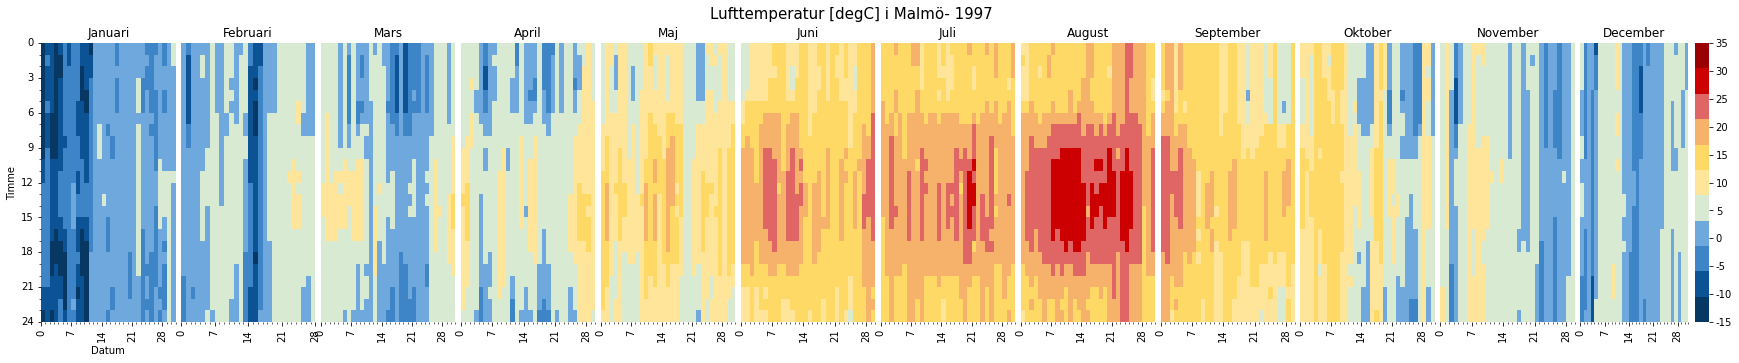

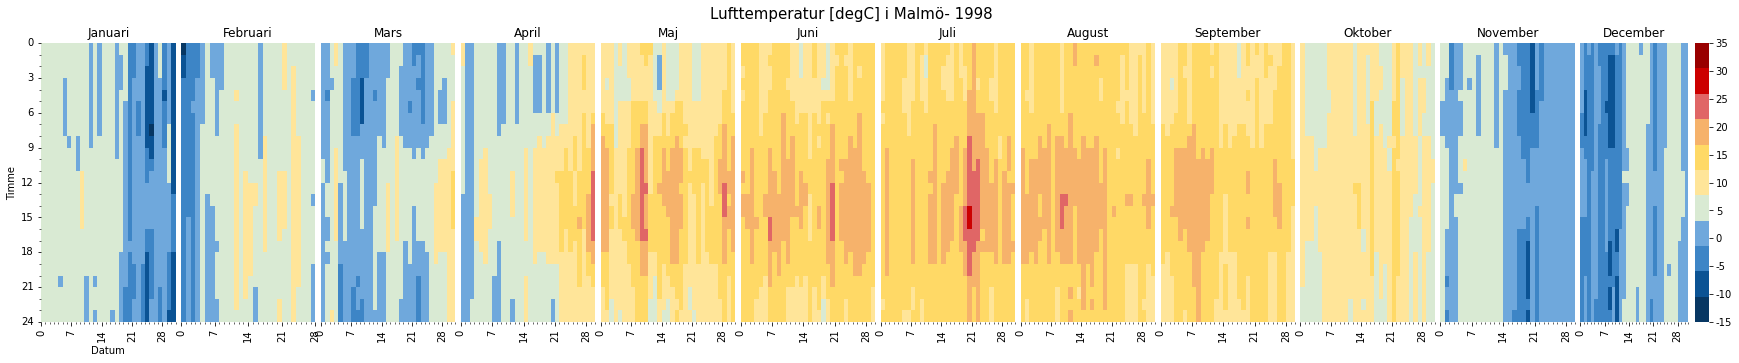

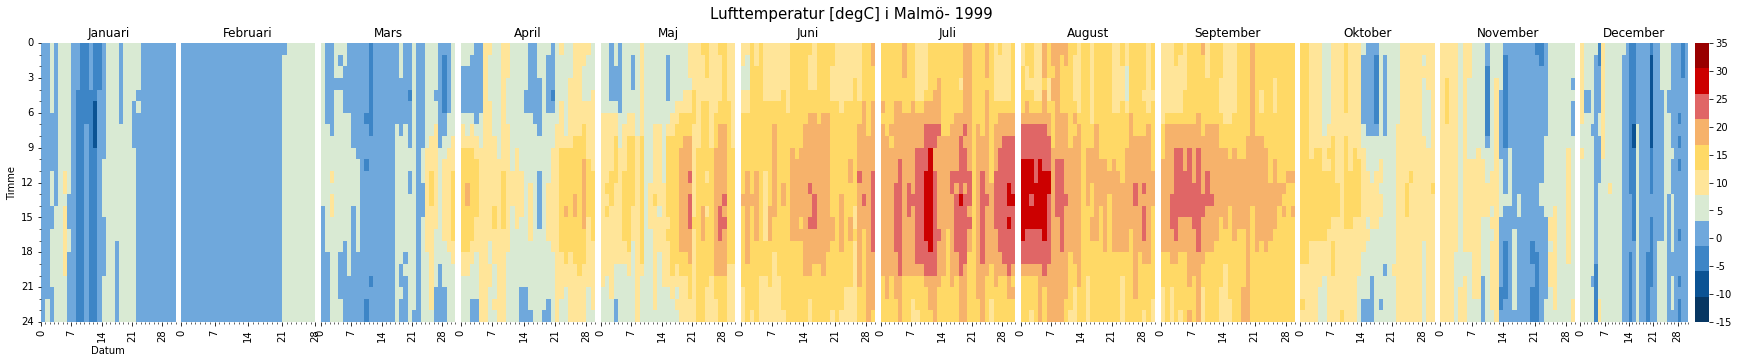

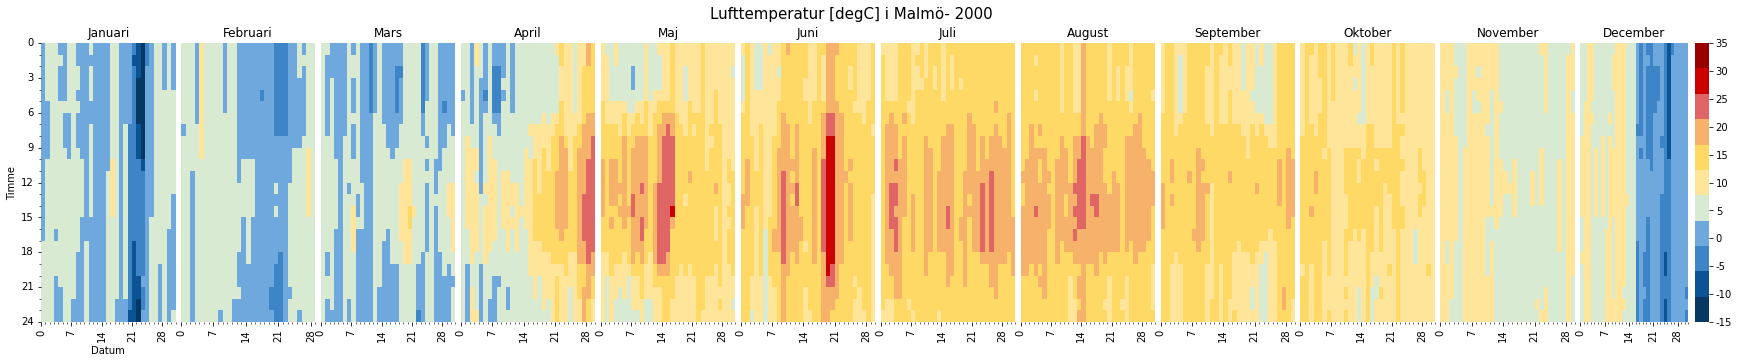

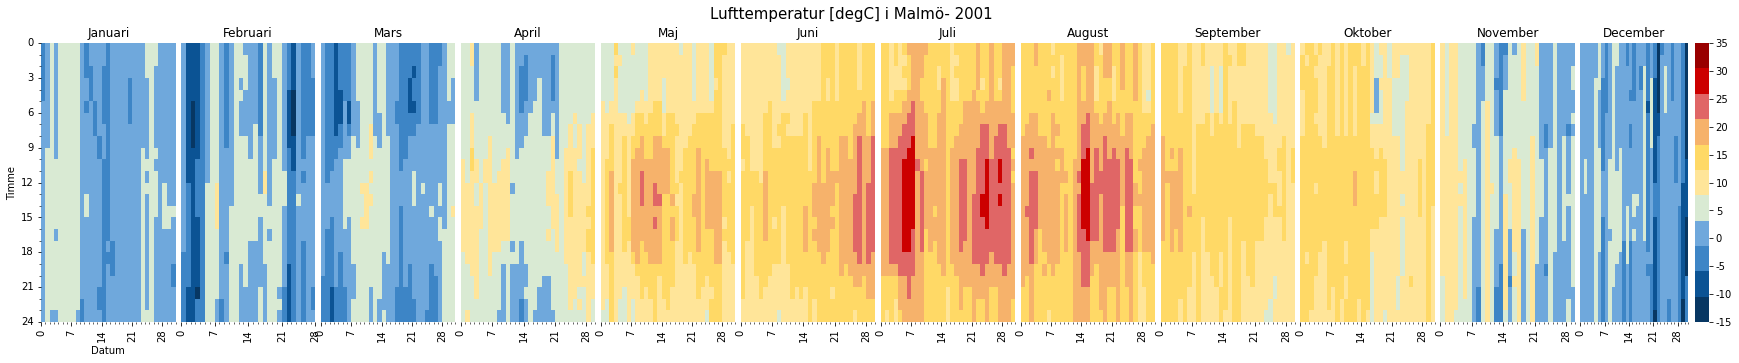

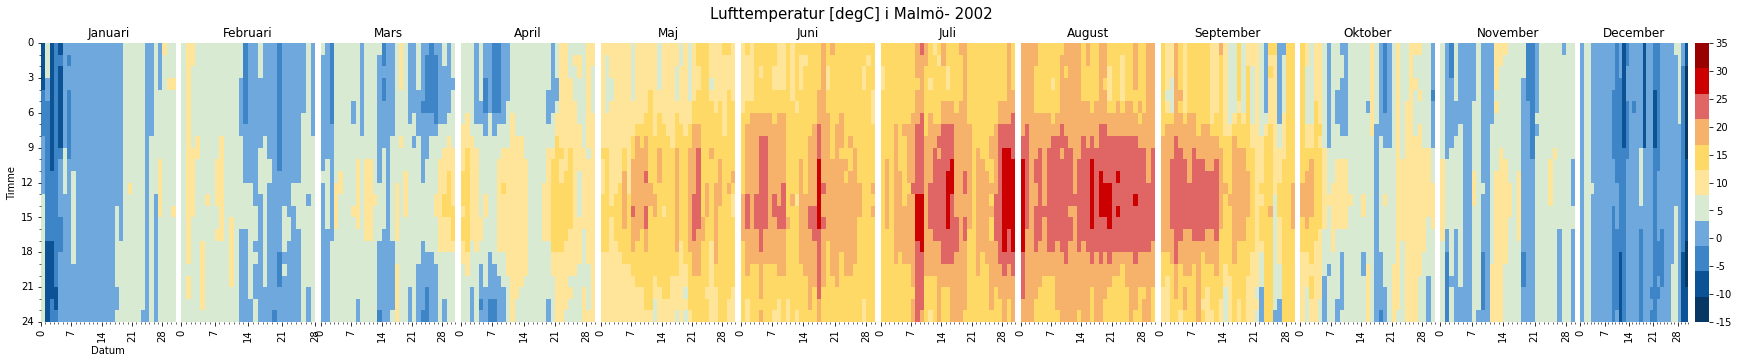

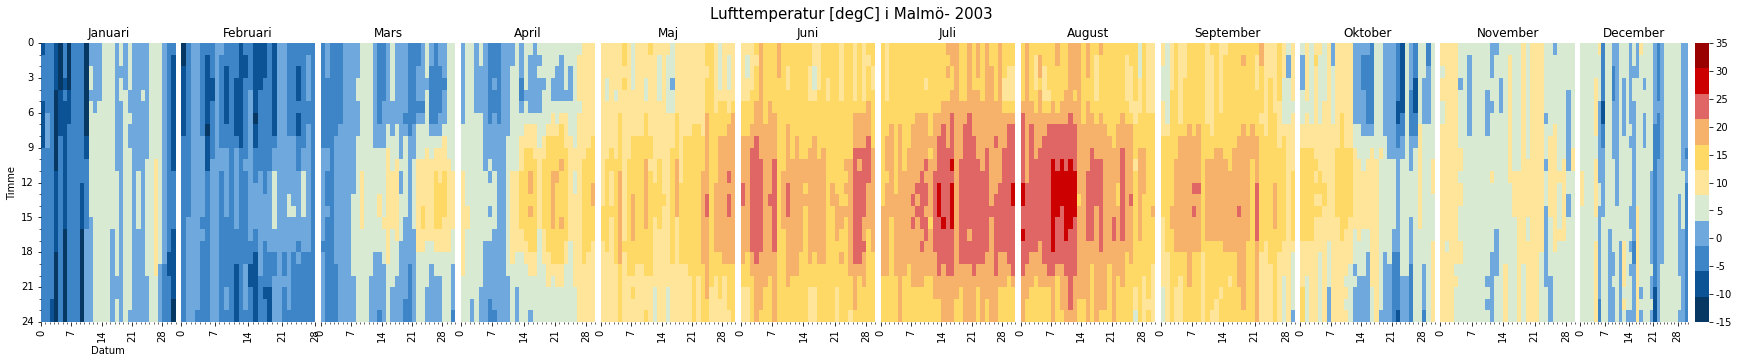

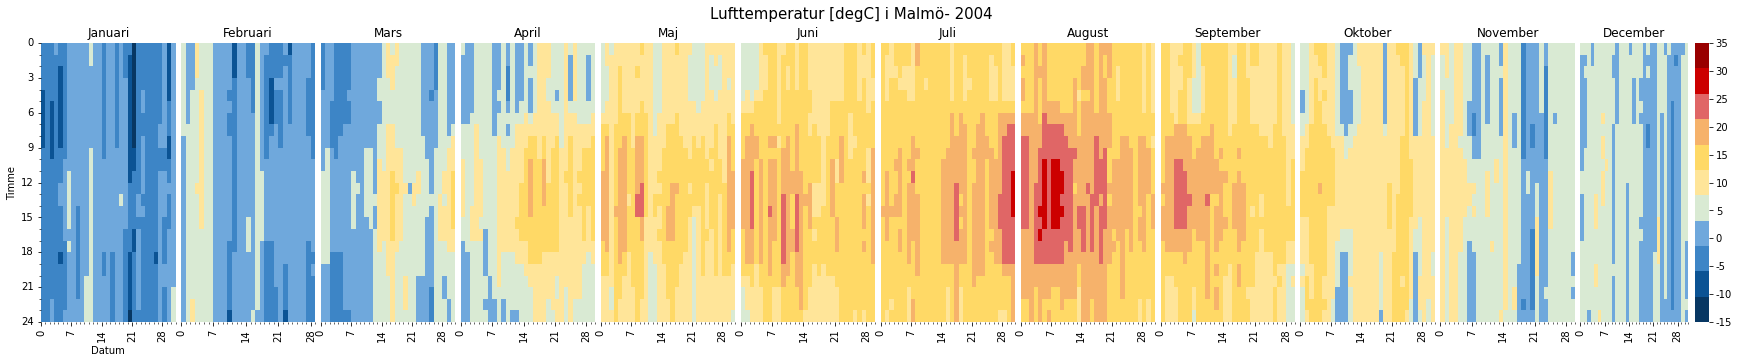

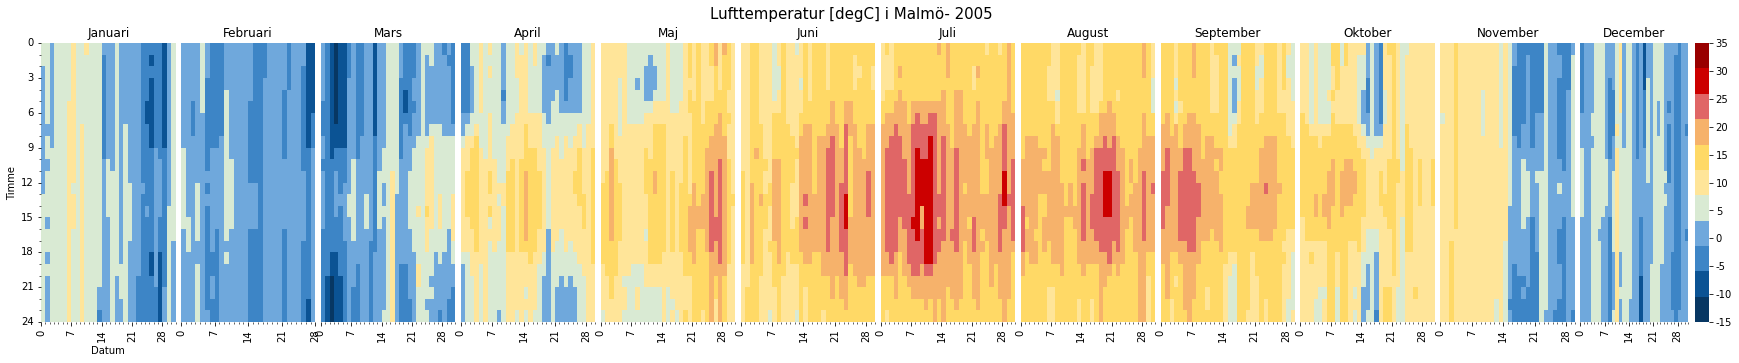

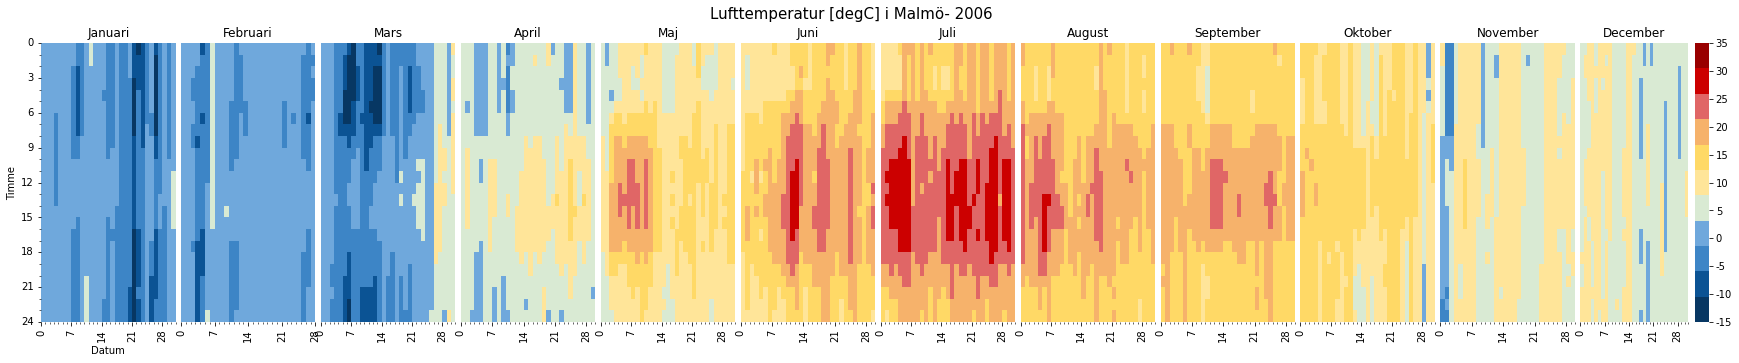

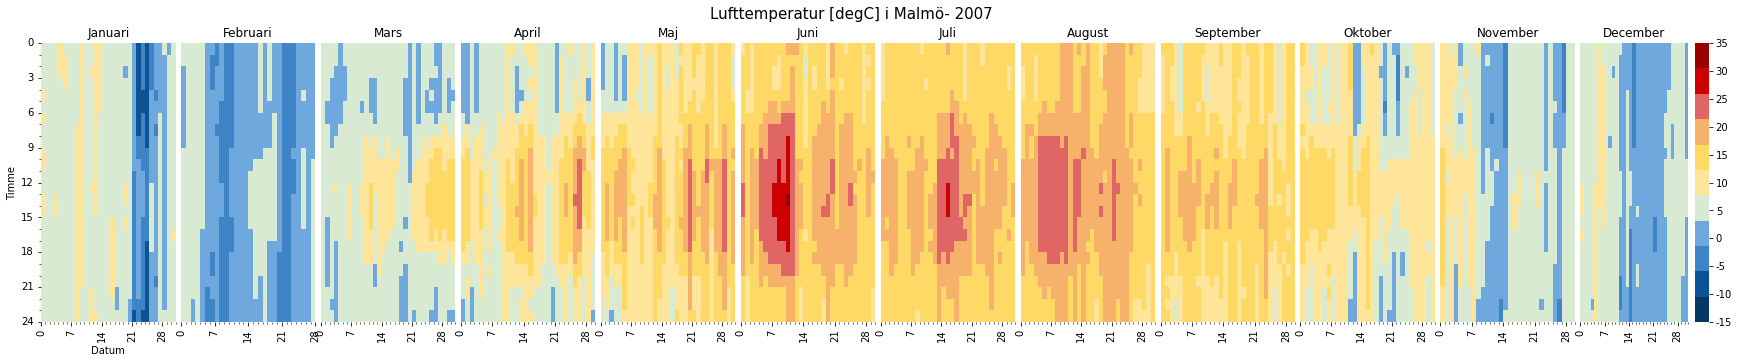

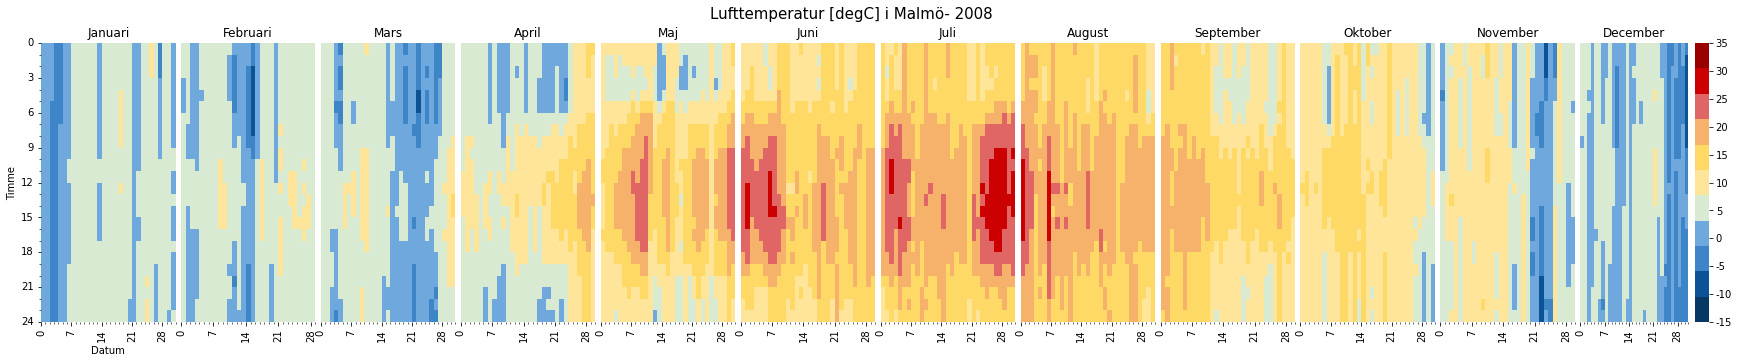

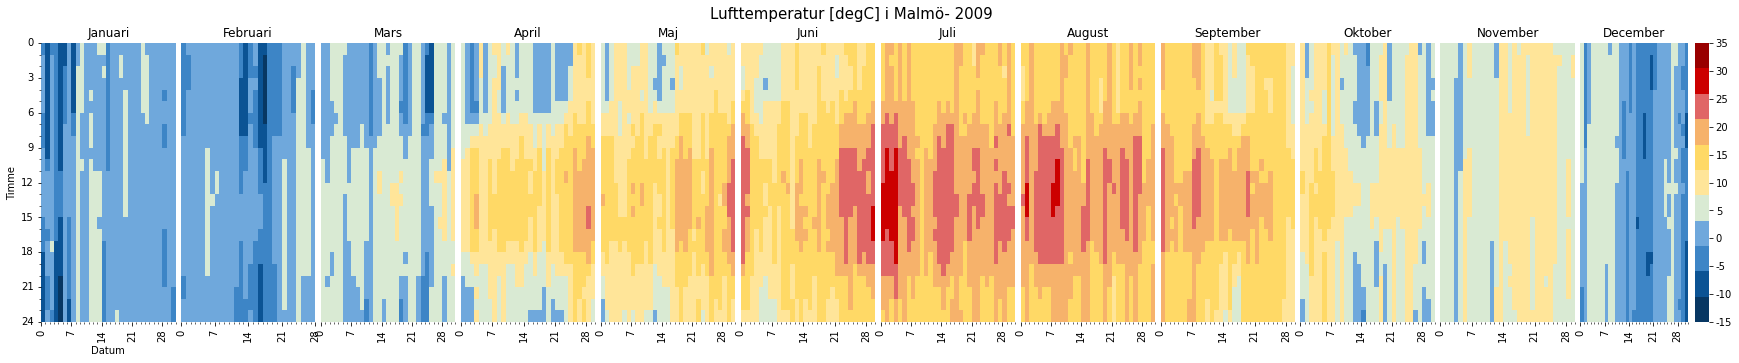

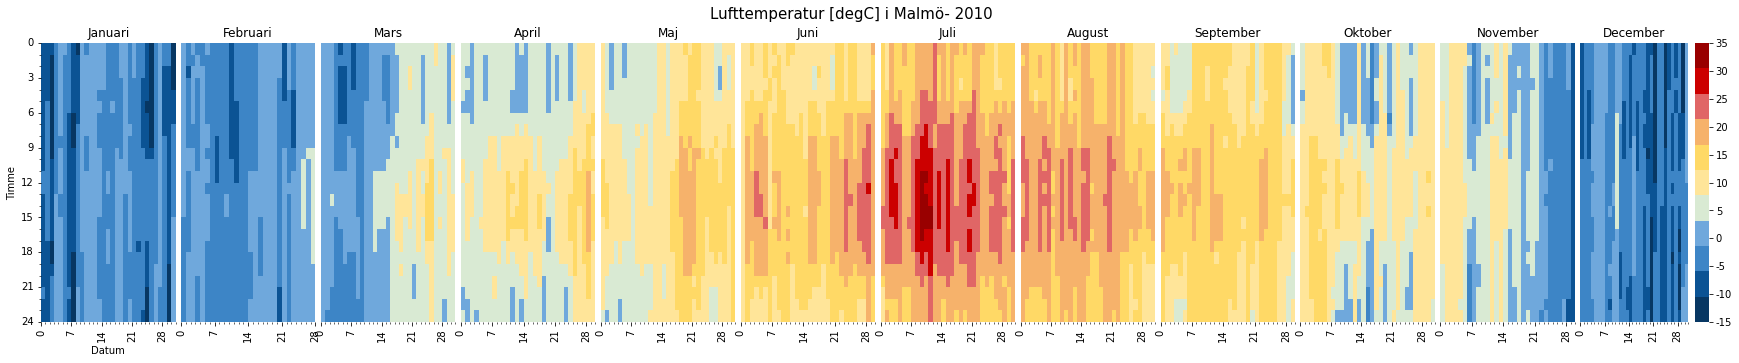

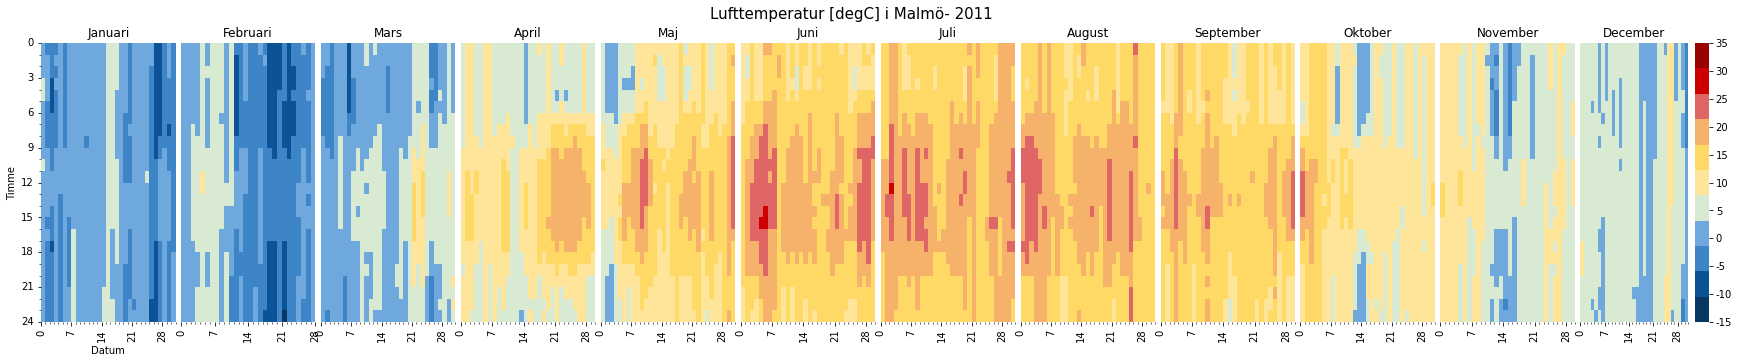

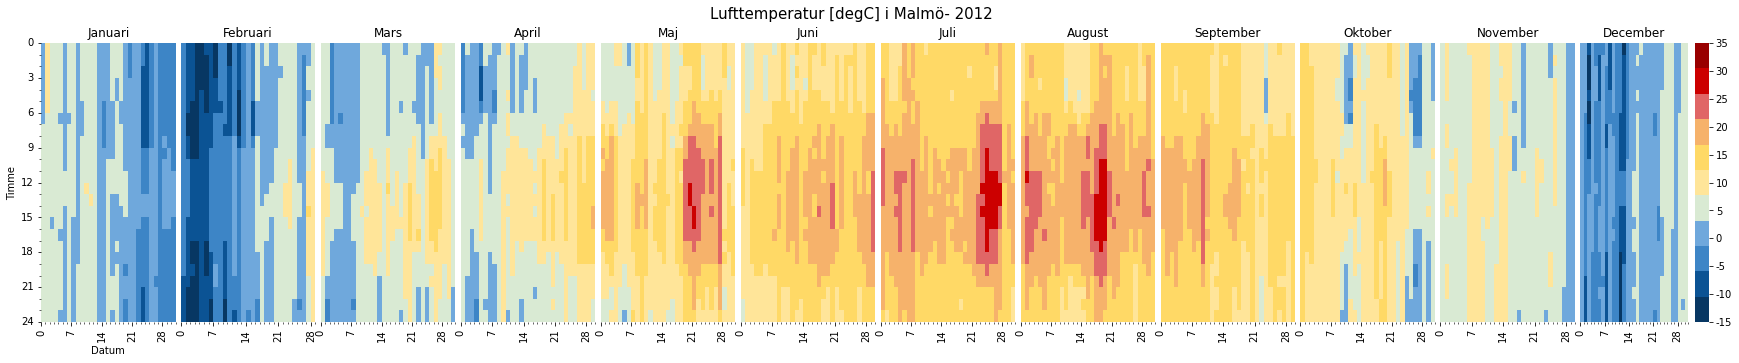

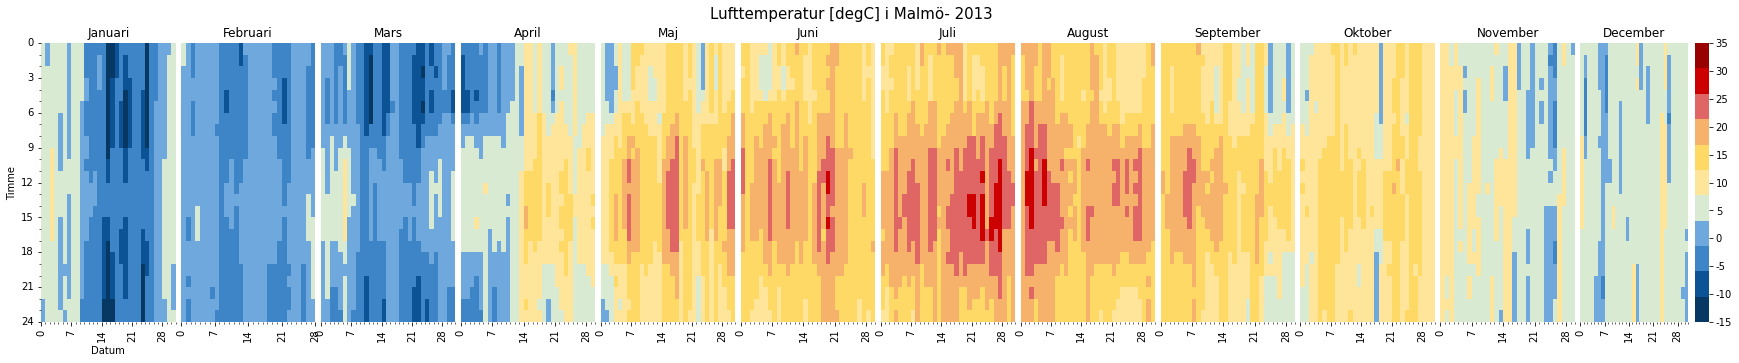

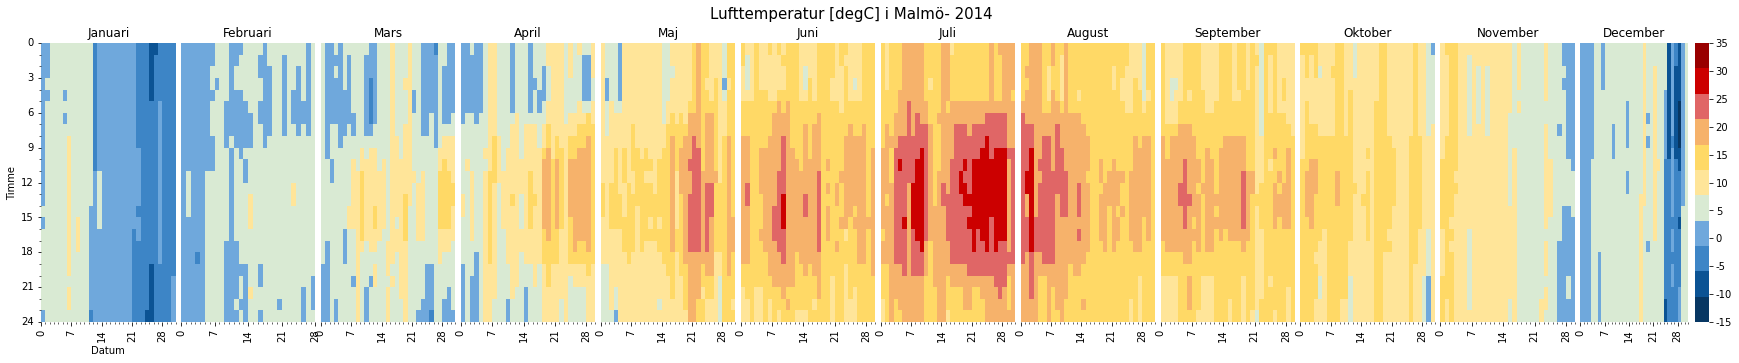

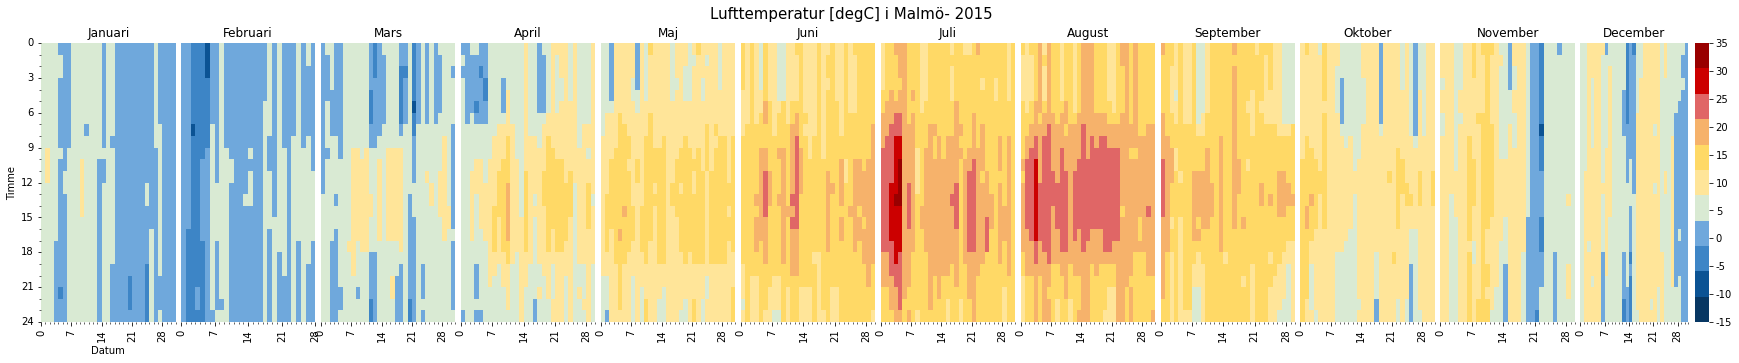

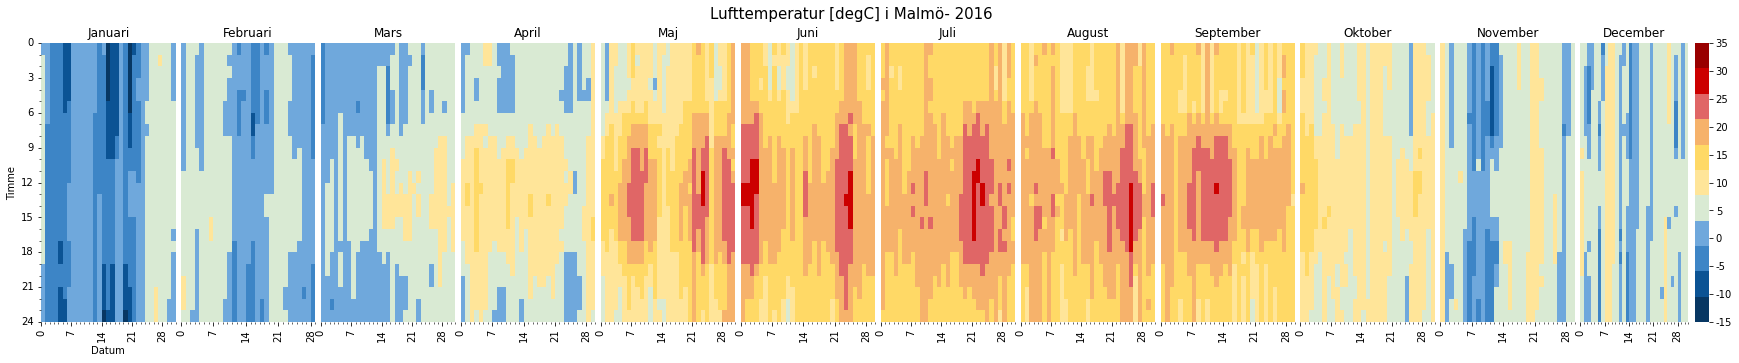

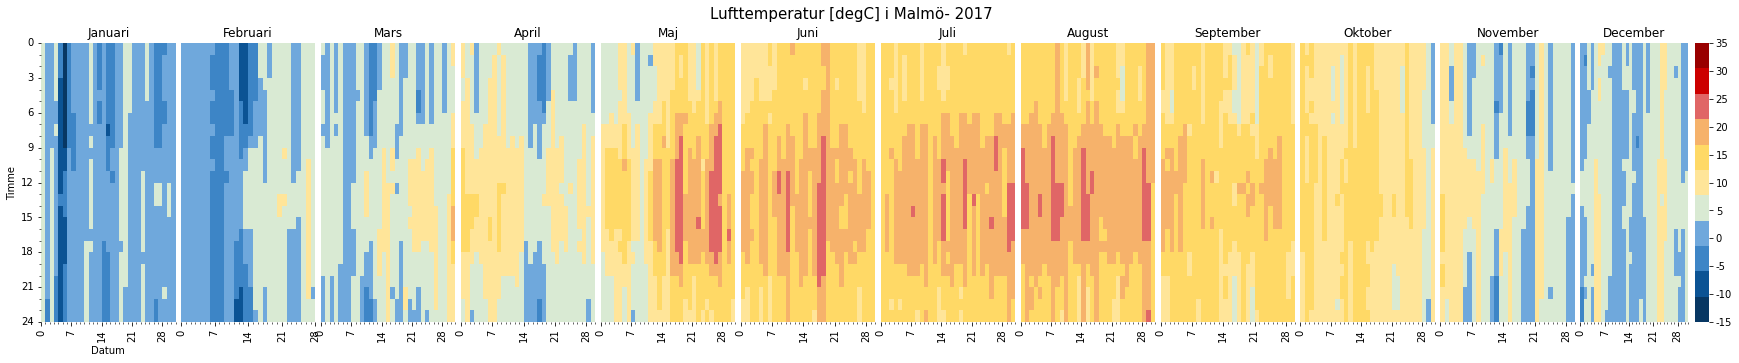

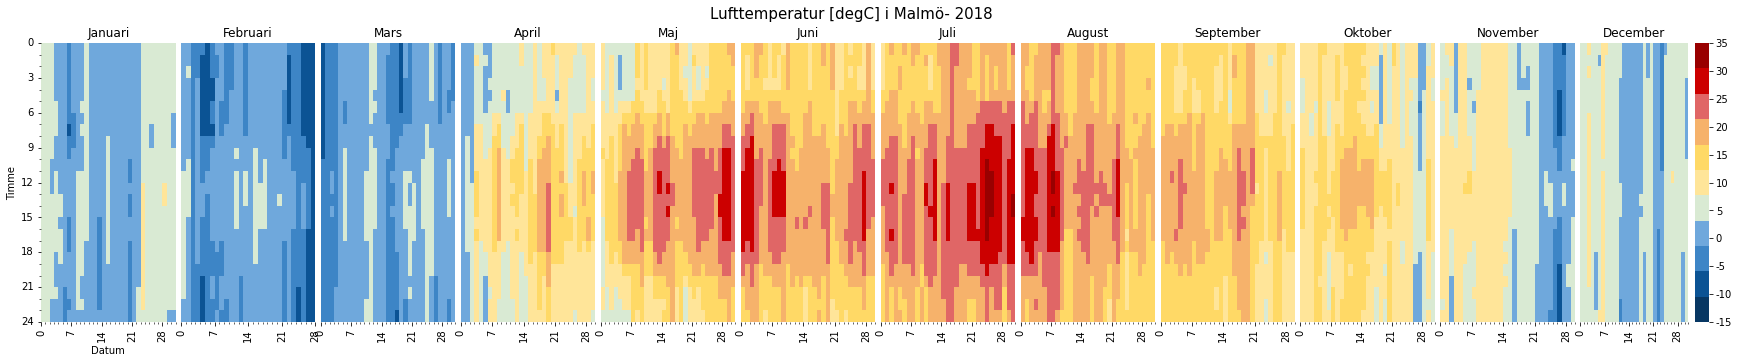

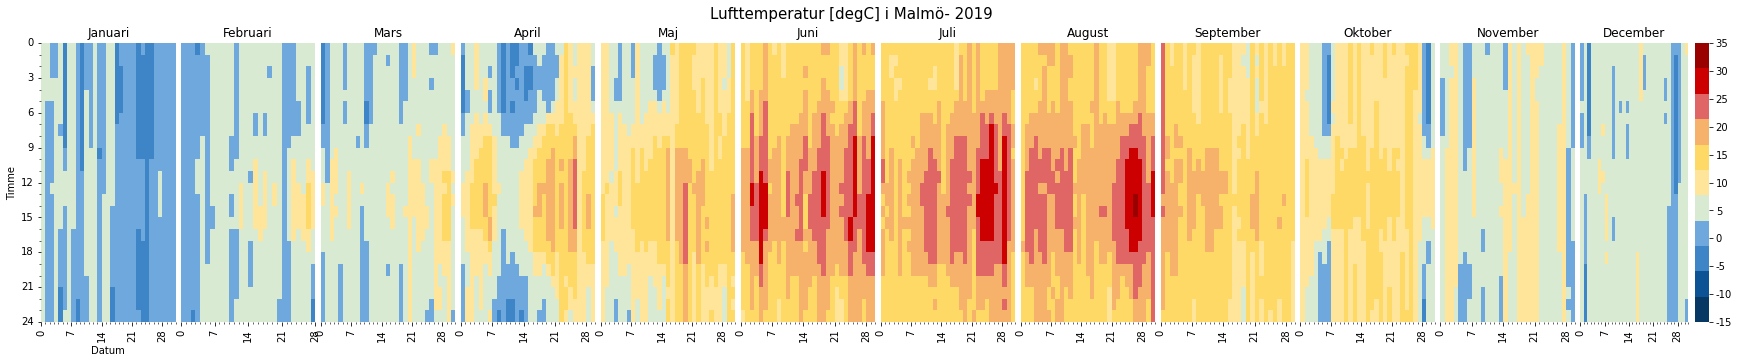

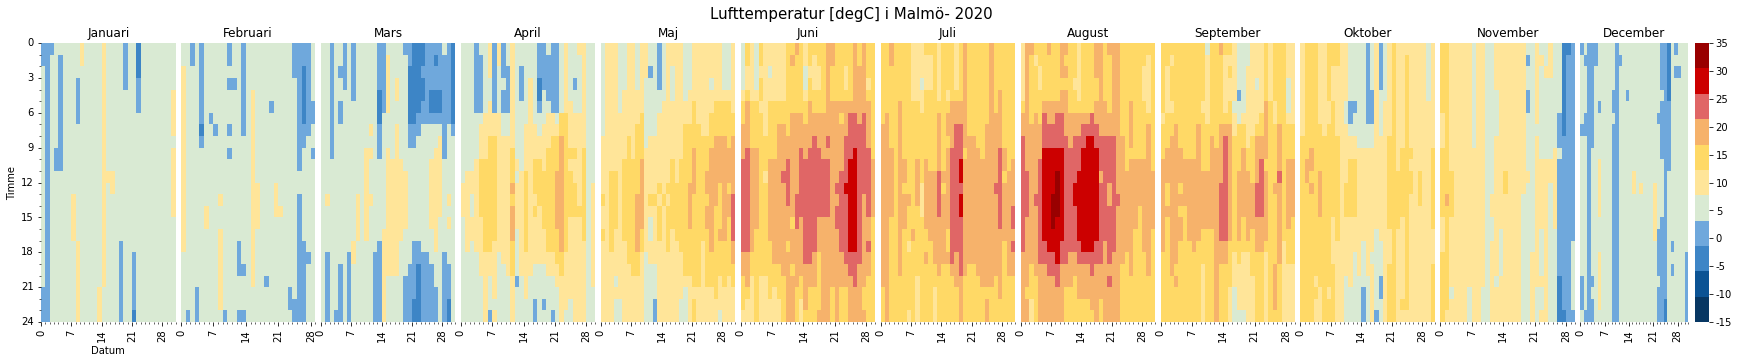

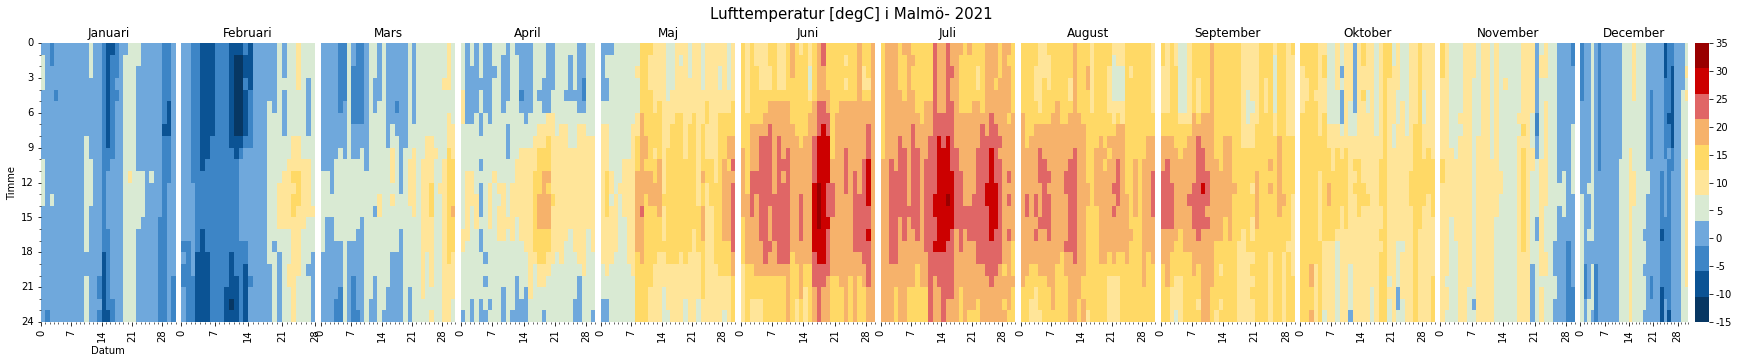

In [358]:
years = range(1997, 2022)
for year in years:
    months = enumerate(range(1, 13))
    fig, axes = plt.subplots(1, 12, figsize=(25, 5), sharey=True,clear=True)
    for i, month in months:
        plot_month(df, month, year, axes[i])
    fig.subplots_adjust(left=0.05, right=0.98, top=0.9, hspace=0.08, wspace=0.04)
    fig.suptitle("Lufttemperatur [degC] i Malmö- " + str(year),fontsize=15,y=1.0)
    plt.show()
    fig.clf()